## Train A Test A

### Classification

Category distribution:
4    6529
0    5431
3     372
2     192
5      61
1      49
6      47
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.64      0.64      0.64      1077
      Button       0.88      0.88      0.88         8
        Door       0.71      0.73      0.72        44
      Motion       0.67      0.63      0.65        65
      Socket       0.71      0.72      0.71      1312
 Temperature       0.82      0.60      0.69        15
   Vibration       0.86      0.38      0.52        16

    accuracy                           0.68      2537
   macro avg       0.75      0.65      0.69      2537
weighted avg       0.68      0.68      0.68      2537

Macro F1-Score: 0.6868


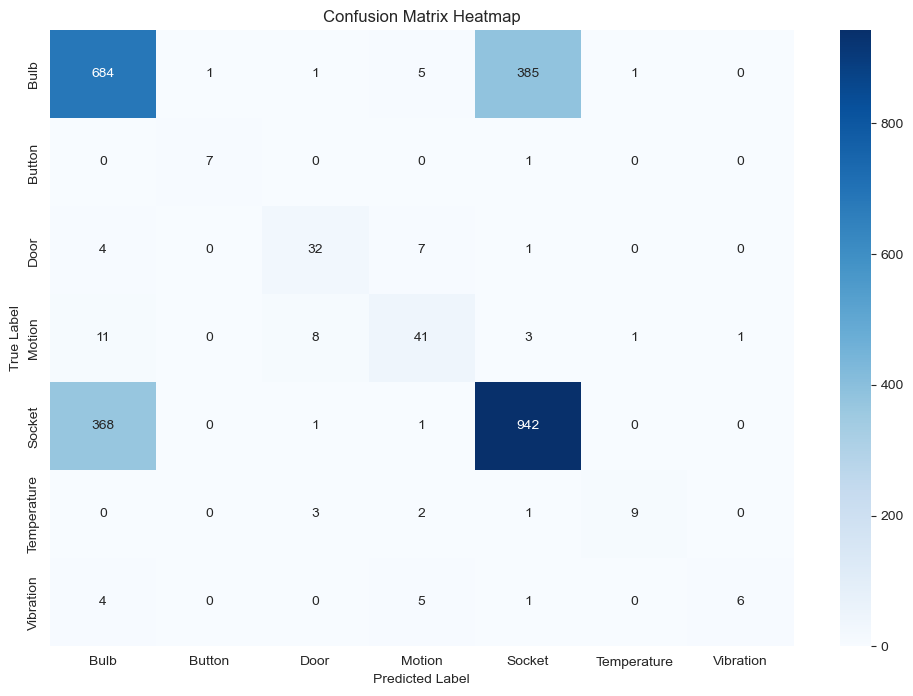

In [17]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    1771
14    1413
13    1404
5     1386
12    1204
8     1192
6     1069
9      899
7      872
10     750
11     173
19      96
1       75
3       62
20      61
0       49
4       47
2       46
16      42
18      41
17      29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.67      1.00      0.80         8
        Aqara Door 1       0.55      0.86      0.67        14
        Aqara Door 2       0.60      0.30      0.40        10
        Aqara Motion       0.82      0.75      0.78        12
     Aqara Vibration       0.83      0.62      0.71        16
       Ledvance Bulb       0.35      0.36      0.35       264
Ledvance Smart+ Plug       0.35      0.32      0.34       220
    Ledvance Z3 Plug       0.20      0.22      0.21       172
           Moes Bulb       0.75      0.86      0.80       247
      Philips Lamp 1       0.14      0.17      0.15       169
      Philips Lamp 2       0.21      

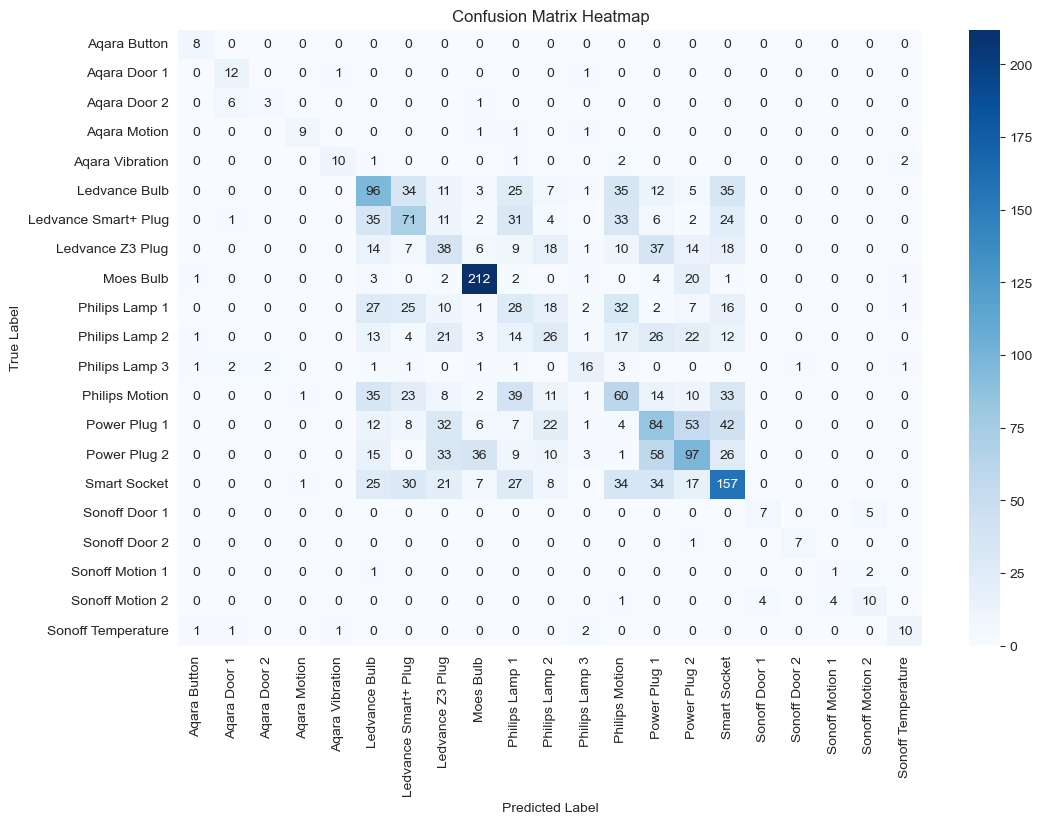

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    9731
0    6867
3     682
2     229
5     146
1     106
6      48
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.64      0.61      0.63      1330
      Button       0.68      0.75      0.71        20
        Door       0.81      0.87      0.84        45
      Motion       0.85      0.73      0.79       143
      Socket       0.73      0.76      0.75      1982
 Temperature       0.82      0.45      0.58        31
   Vibration       0.50      0.18      0.27        11

    accuracy                           0.70      3562
   macro avg       0.72      0.62      0.65      3562
weighted avg       0.70      0.70      0.70      3562

Macro F1-Score: 0.6521


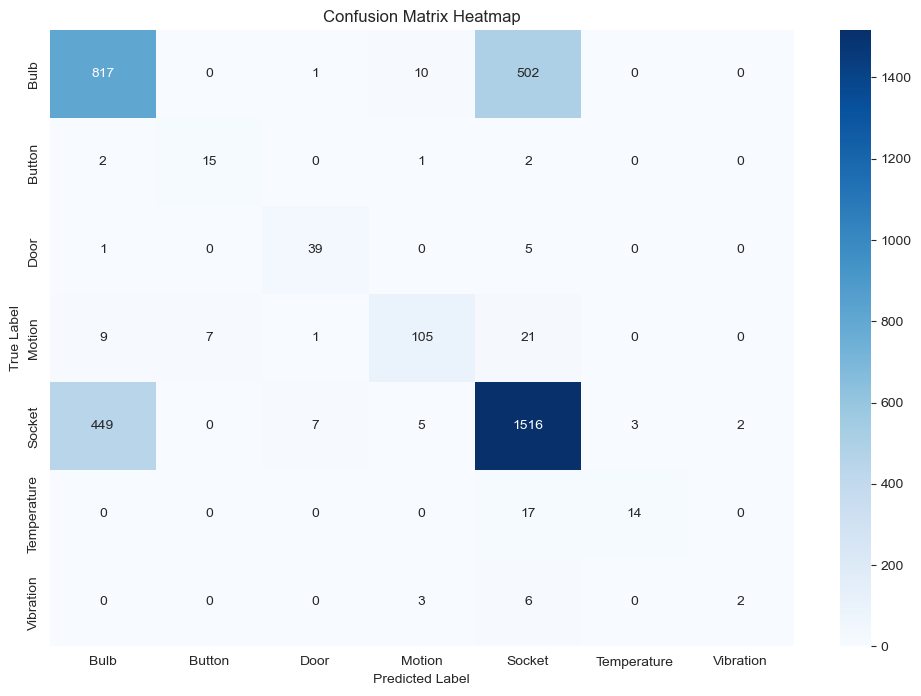

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    2831
13    2712
5     1832
14    1744
8     1535
7     1380
9     1359
11    1333
6     1064
10     808
12     402
3      200
20     146
0      106
16      67
18      59
17      55
1       54
2       53
4       48
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.61      0.85      0.71        20
        Aqara Door 1       0.56      0.82      0.67        11
        Aqara Door 2       0.86      1.00      0.92        12
        Aqara Motion       0.97      0.86      0.91        42
     Aqara Vibration       0.43      0.27      0.33        11
       Ledvance Bulb       0.28      0.30      0.29       338
Ledvance Smart+ Plug       0.14      0.13      0.13       216
    Ledvance Z3 Plug       0.12      0.12      0.12       275
           Moes Bulb       0.54      0.64      0.59       297
      Philips Lamp 1       0.31      0.31      0.31       267
      Philips Lamp 2       0.14      

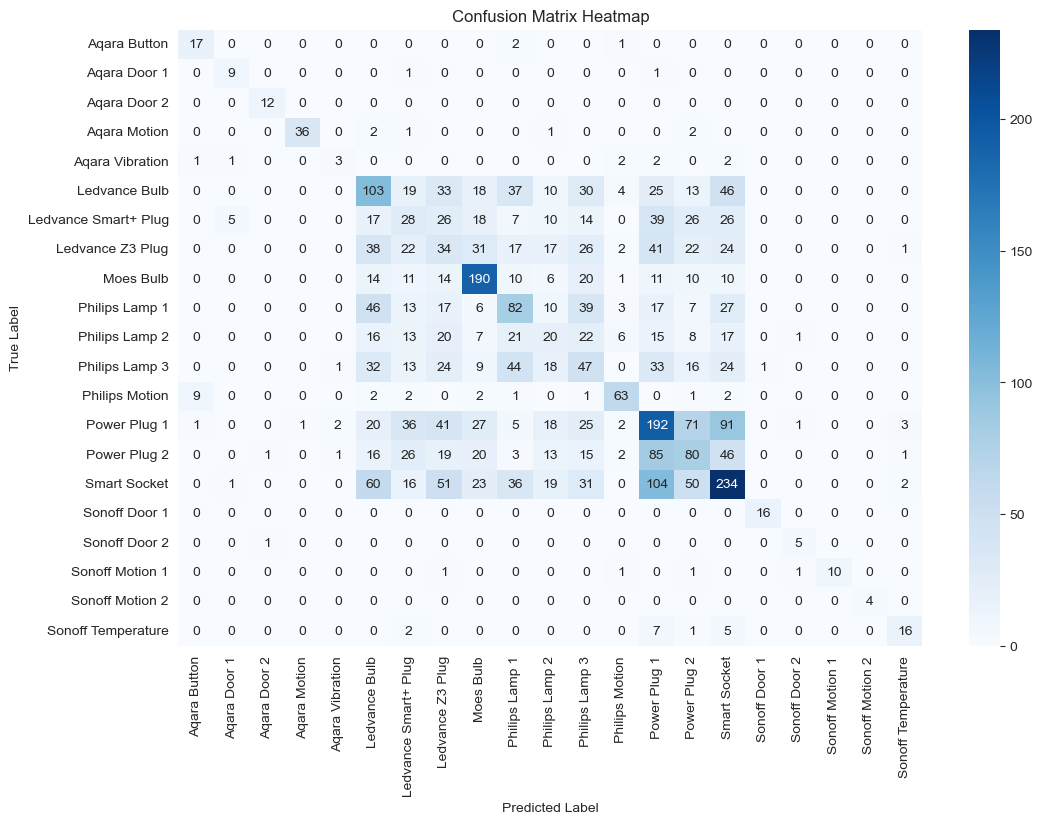

In [20]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    6529
0    5431
3     372
2     192
5      61
1      49
6      47
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.55      0.51      0.53      6867
      Button       0.11      0.08      0.09       106
        Door       0.38      0.24      0.29       229
      Motion       0.51      0.54      0.53       682
      Socket       0.67      0.71      0.69      9731
 Temperature       0.20      0.26      0.23       146
   Vibration       0.10      0.08      0.09        48

    accuracy                           0.61     17809
   macro avg       0.36      0.34      0.35     17809
weighted avg       0.60      0.61      0.61     17809

Macro F1-Score: 0.3482


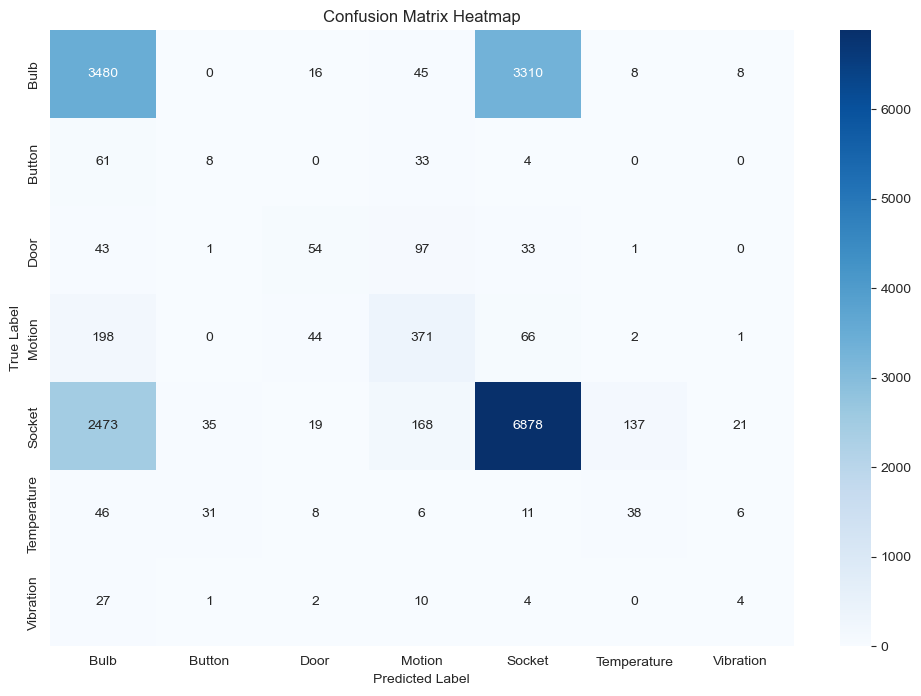

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    1771
14    1413
13    1404
5     1386
12    1204
8     1192
6     1069
9      899
7      872
10     750
11     173
19      96
1       75
3       62
20      61
0       49
4       47
2       46
16      42
18      41
17      29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.08      0.08      0.08       106
        Aqara Door 1       0.00      0.00      0.00        54
        Aqara Door 2       0.25      0.08      0.12        53
        Aqara Motion       0.51      0.47      0.49       200
     Aqara Vibration       0.05      0.08      0.06        48
       Ledvance Bulb       0.31      0.28      0.30      1832
Ledvance Smart+ Plug       0.06      0.07      0.07      1064
    Ledvance Z3 Plug       0.14      0.16      0.15      1380
           Moes Bulb       0.51      0.37      0.43      1535
      Philips Lamp 1       0.18      0.14      0.16      1359
      Philips Lamp 2       0.10      

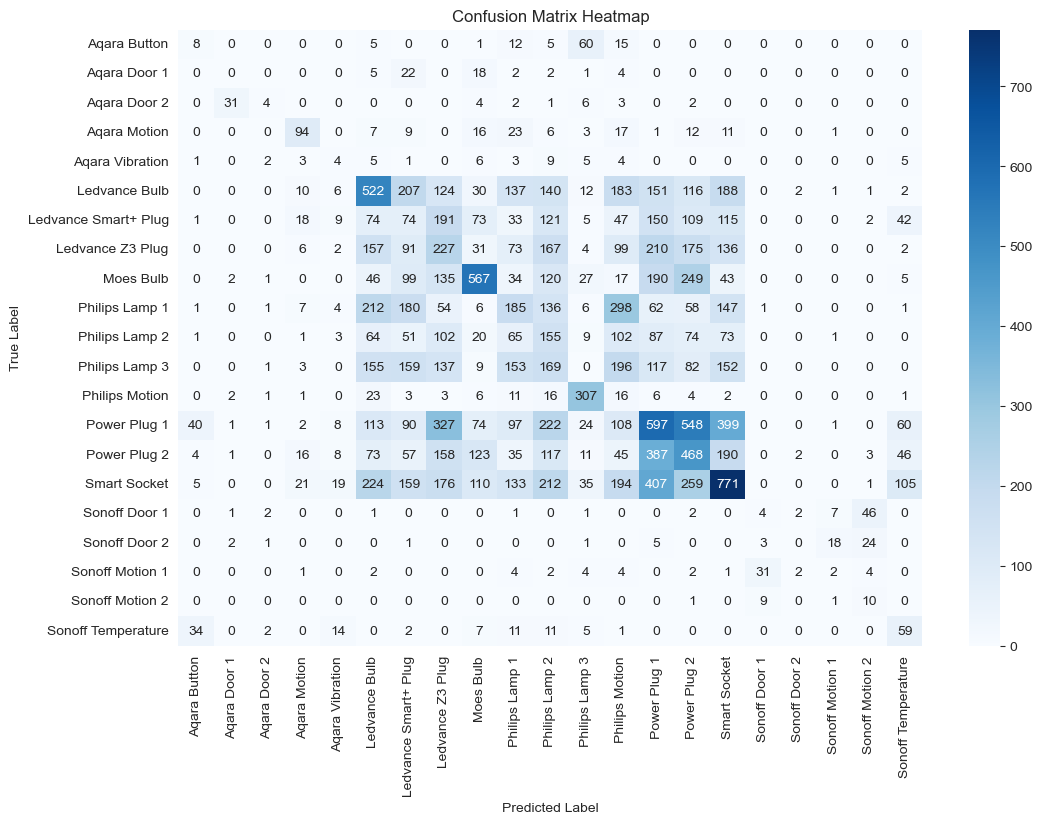

In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    9731
0    6867
3     682
2     229
5     146
1     106
6      48
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.61      0.59      0.60      5431
      Button       0.33      0.02      0.04        49
        Door       0.52      0.60      0.56       192
      Motion       0.62      0.34      0.44       372
      Socket       0.65      0.70      0.67      6529
 Temperature       0.38      0.34      0.36        61
   Vibration       0.50      0.09      0.15        47

    accuracy                           0.63     12681
   macro avg       0.52      0.38      0.40     12681
weighted avg       0.63      0.63      0.63     12681

Macro F1-Score: 0.4026


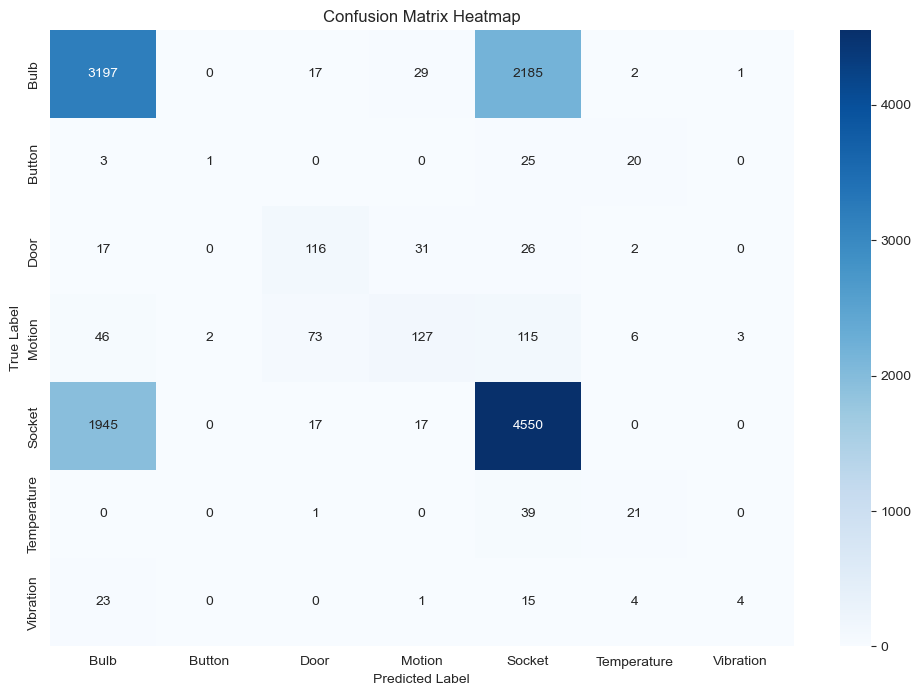

In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    2831
13    2712
5     1832
14    1744
8     1535
7     1380
9     1359
11    1333
6     1064
10     808
12     402
3      200
20     146
0      106
16      67
18      59
17      55
1       54
2       53
4       48
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.38      0.06      0.11        49
        Aqara Door 1       0.00      0.00      0.00        75
        Aqara Door 2       0.23      0.67      0.35        46
        Aqara Motion       0.55      0.52      0.53        62
     Aqara Vibration       0.19      0.06      0.10        47
       Ledvance Bulb       0.31      0.36      0.33      1386
Ledvance Smart+ Plug       0.10      0.06      0.08      1069
    Ledvance Z3 Plug       0.14      0.14      0.14       872
           Moes Bulb       0.55      0.60      0.58      1192
      Philips Lamp 1       0.16      0.24      0.19       899
      Philips Lamp 2       0.14      

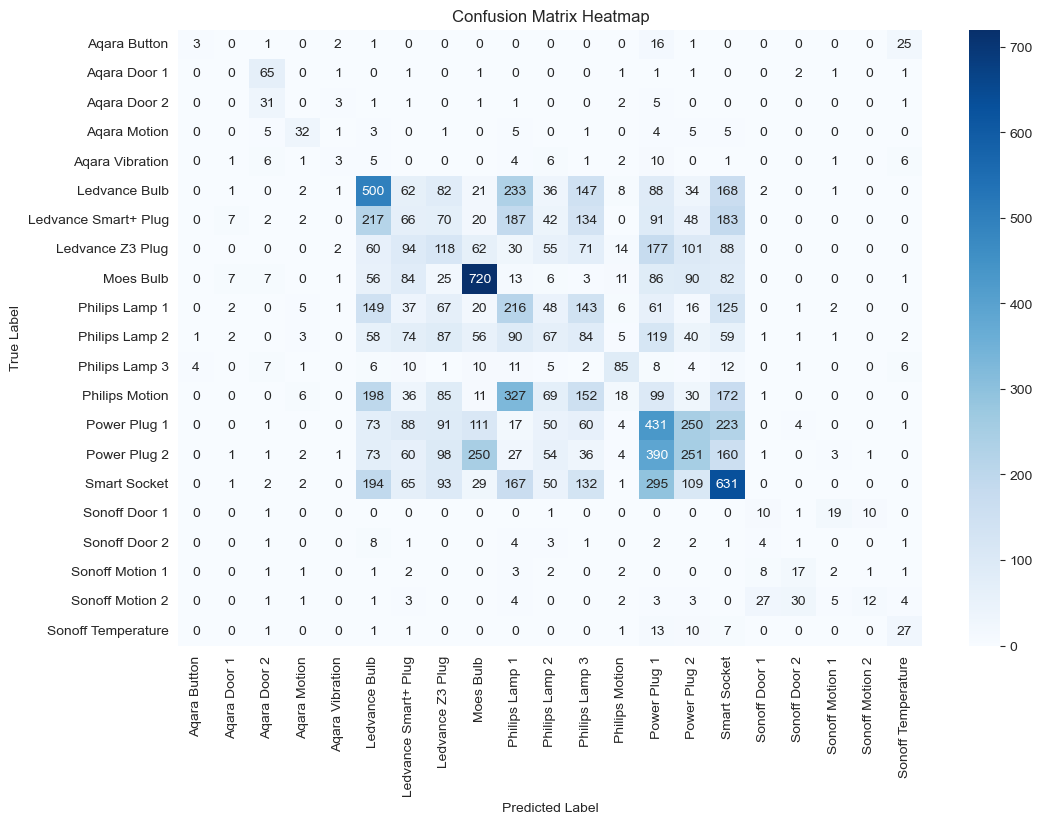

In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
